# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *(replace with your name)*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: akilleshsuresh
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:03<00:00, 113MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [5]:
# Your exploration here

fire_dir = os.path.join(data_dir_fire, "fire_images")
non_fire_dir = os.path.join(data_dir_fire, "non_fire_images")

num_fire = len(os.listdir(fire_dir))
num_non_fire = len(os.listdir(non_fire_dir))
total = num_fire + num_non_fire

print("Fire images:", num_fire)
print("Non-fire images:", num_non_fire)
print("Total images:", total)

print(f"\nFire: {num_fire / total * 100:.1f}%")
print(f"Non-fire: {num_non_fire / total * 100:.1f}%")


Fire images: 755
Non-fire images: 244
Total images: 999

Fire: 75.6%
Non-fire: 24.4%


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

The dataset is imbalanced, with about 75.6% fire images and 24.4% non-fire images. Because of this imbalance, accuracy alone may be misleading since a model could achieve high accuracy by favoring the fire class. The class distribution should be considered when splitting the data and evaluating the model.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [6]:
# Preprocess the data here
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_fire = train_raw_fire.map(
    lambda x, y: (preprocess_input(x), y)
)

val_fire = val_raw_fire.map(
    lambda x, y: (preprocess_input(x), y)
)

test_fire = test_raw_fire.map(
    lambda x, y: (preprocess_input(x), y)
)


In [7]:
# Build your model here
base_model_fire = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained base
base_model_fire.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

# Keep the base model in inference mode
x = base_model_fire(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Binary classification output
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_fire = tf.keras.Model(inputs, outputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# Compile your model here

model_fire.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_fire.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 1D — Train and Evaluate

In [9]:
# Train your model here
history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=10
)


Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7257 - loss: 0.5138 - val_accuracy: 0.8921 - val_loss: 0.2839
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9629 - loss: 0.1788 - val_accuracy: 0.9424 - val_loss: 0.1657
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9714 - loss: 0.1137 - val_accuracy: 0.9568 - val_loss: 0.1110
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9757 - loss: 0.0904 - val_accuracy: 0.9712 - val_loss: 0.0861
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9800 - loss: 0.0777 - val_accuracy: 0.9784 - val_loss: 0.0796
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9857 - loss: 0.0689 - val_accuracy: 0.9640 - val_loss: 0.0907
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9900 - loss: 0.0618 - val_accuracy: 0.9568 - val_loss: 0.0903
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9929 - loss: 0.0568 - val_accuracy: 0.9784 - val_loss:

In [10]:
# Report validation and test accuracy here

val_loss, val_accuracy = model_fire.evaluate(val_fire)
test_loss, test_accuracy = model_fire.evaluate(test_fire)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9856 - loss: 0.0560
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9812 - loss: 0.0784
Validation Accuracy: 98.56%
Test Accuracy: 98.12%


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step


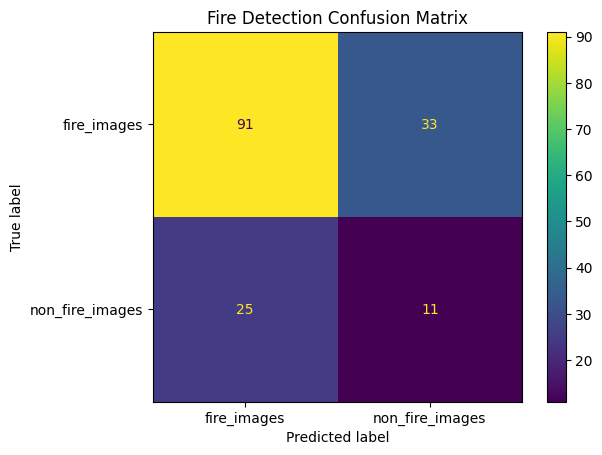

[[91 33]
 [25 11]]


In [11]:
# Build your confusion matrix here

y_true = np.concatenate([y.numpy() for x, y in test_fire])
y_prob = model_fire.predict(test_fire).flatten()
y_pred = (y_prob >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names_fire
)

disp.plot()
plt.title("Fire Detection Confusion Matrix")
plt.show()

print(cm)

*Your answer:*
A false negative would be more costly because missing a real fire could lead to serious property damage or injuries, while a false positive would mainly cause an unnecessary alarm. Because the model labels fire as 0 and non-fire as 1, I would raise the decision threshold above 0.5. This would require the model to be more confident before predicting non-fire, reducing the chance of missing a real fire. However, this could also result in more false alarms, so the threshold would need to be tested to find a reasonable balance.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [12]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [13]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [14]:
# Preprocess the data here
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_sat = train_raw_sat.map(
    lambda x, y: (preprocess_input(x), y)
)

val_sat = val_raw_sat.map(
    lambda x, y: (preprocess_input(x), y)
)

test_sat = test_raw_sat.map(
    lambda x, y: (preprocess_input(x), y)
)


In [18]:
# Build your model here

base_model_sat = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model_sat(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

model_sat = tf.keras.Model(inputs, outputs)


In [19]:
# Compile your model here

model_sat.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_sat.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2C — Train and Evaluate

In [20]:
# Train your model here
history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=10
)


Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1049s 2s/step - accuracy: 0.8793 - loss: 0.3679 - val_accuracy: 0.9336 - val_loss: 0.2156
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1038s 2s/step - accuracy: 0.9348 - loss: 0.1948 - val_accuracy: 0.9410 - val_loss: 0.1892
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1008s 2s/step - accuracy: 0.9469 - loss: 0.1592 - val_accuracy: 0.9410 - val_loss: 0.1842
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1034s 2s/step - accuracy: 0.9542 - loss: 0.1382 - val_accuracy: 0.9393 - val_loss: 0.1798
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1034s 2s/step - accuracy: 0.9601 - loss: 0.1216 - val_accuracy: 0.9403 - val_loss: 0.1759
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1019s 2s/step - accuracy: 0.9637 - loss: 0.1100 - val_accuracy: 0.9376 - val_loss: 0.1873
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1039s 2s/step - accuracy: 0.9685 - loss: 0.0987 - val_accuracy: 0.9376 - val_loss: 0.1829
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 1048s 2s/step - accuracy: 0.9708 - loss: 0.0919 - 

In [21]:
# Report validation and test accuracy here
val_loss, val_accuracy = model_sat.evaluate(val_sat)
test_loss, test_accuracy = model_sat.evaluate(test_sat)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


127/127 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9430 - loss: 0.1717
127/127 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.9409 - loss: 0.1741
Validation Accuracy: 94.30%
Test Accuracy: 94.09%


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

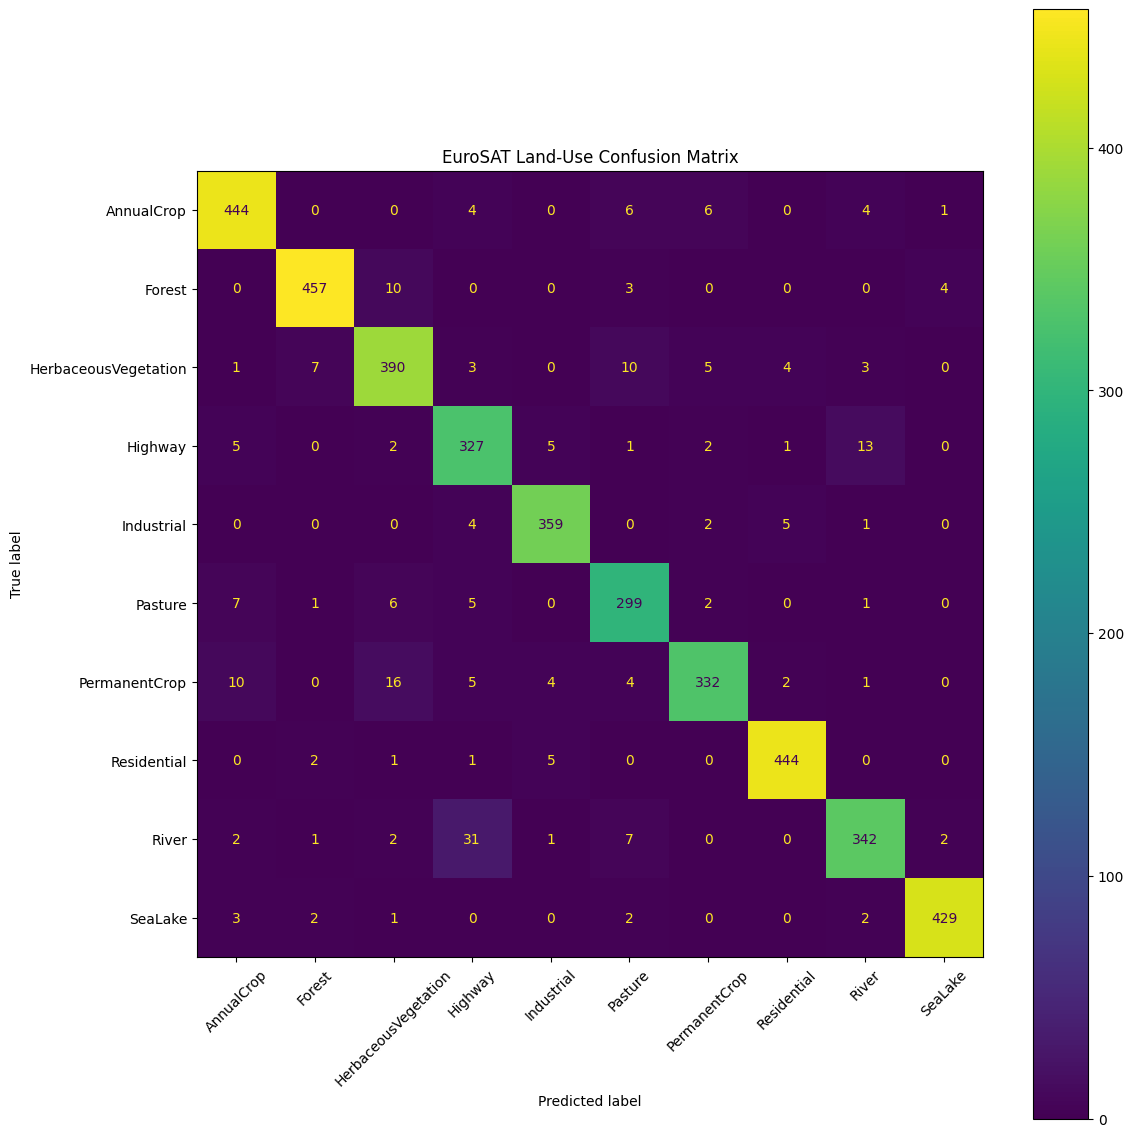

In [23]:
# Build your confusion matrix here
y_true_sat = []
y_pred_sat = []

for images, labels in test_sat:
    predictions = model_sat.predict(images, verbose=0)

    y_true_sat.extend(labels.numpy())
    y_pred_sat.extend(np.argmax(predictions, axis=1))

y_true_sat = np.array(y_true_sat)
y_pred_sat = np.array(y_pred_sat)

cm_sat = confusion_matrix(y_true_sat, y_pred_sat)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sat,
    display_labels=class_names_sat
)

disp.plot(ax=ax, xticks_rotation=45)
plt.title("EuroSAT Land-Use Confusion Matrix")
plt.tight_layout()
plt.show()


*Your answer:* The model most often confused River with Highway, with 31 River images being classified as Highway and 13 Highway images being classified as River. PermanentCrop was also sometimes confused with HerbaceousVegetation and AnnualCrop. This makes visual sense because rivers and highways can both appear as long, narrow features in satellite images, while the different vegetation and crop classes can have similar colors, textures, and field patterns when viewed from above.




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |98.56% |94.30% |
| Test Accuracy |98.12% |94.09% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.


2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?



*Your answers:*

1) The Fire/Smoke dataset seems to be the closer match to MobileNetV2's original ImageNet training because both contain more ordinary ground-level visual features, while EuroSAT consists of satellite images taken from above. The results support this because the Fire/Smoke model reached 98.12% test accuracy, compared with 94.09% for EuroSAT. EuroSAT is therefore the bigger mismatch, although transfer learning still worked well on it.


2) I think both datasets could potentially improve through fine-tuning, but I would expect it to matter more for EuroSAT. Since satellite imagery is more different from the ImageNet images MobileNetV2 was originally trained on, adjusting some of the pretrained layers could allow the model to learn features that are more specific to satellite imagery. The Fire/Smoke model already reached over 98% test accuracy with the base frozen, so there seems to be less room for improvement there.




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

The Fire dataset was imbalanced, with about 75.6% fire images and 24.4% non-fire images, so I had to consider that when evaluating the model because accuracy alone could be misleading. In Part 1, I used one output neuron with a sigmoid activation and binary crossentropy because there were only two classes. In Part 2, I used 10 output neurons with softmax and sparse categorical crossentropy because EuroSAT had 10 different classes represented by integer labels. The pretrained MobileNetV2 performed well on both datasets, but it performed better on Fire/Smoke, reaching 98.12% test accuracy compared with 94.09% on EuroSAT. This suggests that transfer learning depends not only on the quality of the pretrained model, but also on how closely its original training data matches the new task.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.